# Quantum Sensing Optimization with JAX

Gradient-based optimization of quantum sensing protocols using JAX automatic differentiation.
Optimizes rotation angles θ₁, θ₂ to maximize photon detection sensitivity in a three-system composite space.

## Import Libraries

Essential libraries for JAX-compatible quantum optimization and visualization.

In [74]:
import jax
import jax.numpy as jnp
import qutip as qt
import qutip_jax    
import numpy as np
import matplotlib.pyplot as plt
import optax
import warnings
from jax.scipy.special import erfc

# Suppress Diffrax complex dtype warnings
warnings.filterwarnings('ignore', message='Complex dtype support in Diffrax is a work in progress*')

# Verify library versions
print("JAX version:", jax.__version__)
print("QuTiP version:", qt.__version__)

JAX version: 0.4.35
QuTiP version: 5.2.0


## System Parameters

Physical parameters for the three-system composite Hilbert space and noise settings.

In [75]:
# Physical coupling parameters
gm = 0.03 * 2 * np.pi                # Photon-cavity coupling strength
sigma = 0.1 * gm                     # Inverse pulse width (σ = 2√ln(2)/t_pulse)
chi = 0.5 * gm                       # Dispersive coupling strength
args = {'sigma': sigma}              # Arguments for time-dependent functions

# System dimensions
nlev = 2                             # Cavity levels (input + resonator)
qlev = 2                             # Qubit levels
N_meas = 5                           # Number of measurements

# Measurement timing parameters
tstep = 2.5 / sigma                  # Time step between measurements
tmeas_var = 0.1 / sigma              # Measurement time variance
tstart = -(N_meas - 1) * tstep / 2
tend = -tstart
tmeas = np.linspace(tstart, tend, N_meas)

# Noise parameters (in angular frequency units)
gamma_depol = 0.000 * 2 * np.pi     # Depolarizing noise rate
gamma_dephase = 0.000 * 2 * np.pi   # Dephasing noise rate
gamma_relax = 0.000 * 2 * np.pi     # Relaxation noise rate

# Noise and timing toggles
trand_global = False                  # Random global time offset
trand_single = False                 # Random individual measurement offset
tstep_train = False                  # Variable measurement step training

print(f"System parameters:")
print(f"  Cavity levels: {nlev}")
print(f"  Photon-cavity coupling (γ): {gm:.6f}")
print(f"  Pulse width parameter (σ): {sigma:.6f}")
print(f"  Dispersive coupling (χ): {chi:.6f}")
print(f"  Measurements: {tmeas}")

System parameters:
  Cavity levels: 2
  Photon-cavity coupling (γ): 0.188496
  Pulse width parameter (σ): 0.018850
  Dispersive coupling (χ): 0.094248
  Measurements: [-265.25823849 -132.62911924    0.          132.62911924  265.25823849]


## Quantum Operators

Define operators for the composite Hilbert space: input cavity ⊗ resonator cavity ⊗ qubit.

In [76]:
with qt.CoreOptions(default_dtype="jax"):
    # Identity operators for subsystems
    Iq = qt.identity(qlev)           # Qubit identity (2×2)
    In = qt.identity(nlev)           # Cavity identity (nlev×nlev)
    
    # Cavity operators
    An = qt.destroy(nlev)            # Annihilation operator
    Acn = qt.create(nlev)            # Creation operator
    
    # Pauli matrices for qubit operations
    Sz = qt.sigmaz()                 # Pauli Z
    Sx = qt.sigmax()                 # Pauli X
    Sy = qt.sigmay()                 # Pauli Y (fixed from sigmax)
    Sp = qt.sigmap()                 # Pauli raising operator
    Sm = qt.sigmam()                 # Pauli lowering operator
    
    # Qubit measurement projectors
    P0 = qt.Qobj([[1, 0], [0, 0]])  # Ground state |0⟩⟨0|
    P1 = qt.Qobj([[0, 0], [0, 1]])  # Excited state |1⟩⟨1|

print("✓ Individual subsystem operators defined")

# Composite system operators in input ⊗ resonator ⊗ qubit space
with qt.CoreOptions(default_dtype="jax"):
    # Input cavity operators (first subsystem)
    ain = qt.tensor(An, In, Iq)      # Input photon annihilation
    ainc = ain.dag()                 # Input photon creation
    
    # Resonator cavity operators (second subsystem)  
    a = qt.tensor(In, An, Iq)        # Resonator photon annihilation
    ac = a.dag()                     # Resonator photon creation
    
    # Qubit operators in composite space (third subsystem)
    sz1 = qt.tensor(In, In, Sz)      # Pauli Z in composite space
    sx1 = qt.tensor(In, In, Sx)      # Pauli X in composite space
    sy1 = qt.tensor(In, In, Sy)      # Pauli Y in composite space
    sp1 = qt.tensor(In, In, Sp)      # Pauli + in composite space
    sm1 = qt.tensor(In, In, Sm)      # Pauli - in composite space
    
    # Measurement projectors in composite space
    p0 = qt.tensor(In, In, P0)       # Ground state measurement
    p1 = qt.tensor(In, In, P1)       # Excited state measurement

print("✓ Composite system operators constructed")
print(f"✓ Total Hilbert space dimension: {nlev * nlev * qlev}")

✓ Individual subsystem operators defined
✓ Composite system operators constructed
✓ Total Hilbert space dimension: 8


## JAX-Compatible Quantum Functions

Core quantum operations for rotation gates, measurements, and time-dependent dynamics.

In [77]:
@jax.jit
def ry(rho, theta):
    """Apply Ry rotation to qubit in composite space.
    
    Args:
        rho: QuTiP Qobj density matrix (input ⊗ resonator ⊗ qubit)
        theta: Rotation angle in radians
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    with qt.CoreOptions(default_dtype="jax"):
        Sy_jax = qt.sigmay()
        ry_gate = (-1j * Sy_jax * theta / 2).expm()
        r = qt.tensor(In, In, ry_gate)
        return r * rho * r.dag()


def proj0(rho):
    """Project density matrix onto qubit |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        QuTiP Qobj: Projected density matrix P₀ρP₀† (unnormalized)
    """
    return p0 * rho * p0.dag()


def proj1(rho):
    """Project density matrix onto qubit |1⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        QuTiP Qobj: Projected density matrix P₁ρP₁† (unnormalized)
    """
    return p1 * rho * p1.dag()


def prob0(rho):
    """Calculate probability of measuring qubit in |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        JAX array: Probability Tr(P₀ρ) ∈ [0,1]
    """
    return jnp.real(proj0(rho).tr())


def prob1(rho):
    """Calculate probability of measuring qubit in |1⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        JAX array: Probability Tr(P₁ρ) ∈ [0,1]
    """
    return jnp.real(proj1(rho).tr())


@jax.jit
def gu(t, **kwargs):  
    """Time-dependent Gaussian coupling function.
    
    Args:
        t: Time variable
        **kwargs: Must contain 'sigma' parameter (pulse bandwidth)
        
    Returns:
        JAX array: Normalized coupling strength g(t)
    """
    sigma = kwargs.get("sigma", 0.1)
    dx = sigma * t
    coupling = jnp.sqrt(2 * sigma / jnp.sqrt(jnp.pi) * jnp.exp(-dx**2) / erfc(dx))
    return jnp.array(coupling, dtype=float)

print("✓ JAX-compatible quantum functions defined")

✓ JAX-compatible quantum functions defined


## Hamiltonian and Solver Setup

Construct time-dependent Hamiltonian and configure quantum evolution solvers.

In [78]:
with qt.CoreOptions(default_dtype="jax"):    
    # Time-dependent cavity-cavity coupling Hamiltonian
    Hc = qt.Qobj(1j/2 * jnp.sqrt(gm) * (ainc*a - ain*ac))
    
    # Dispersive qubit-resonator interaction Hamiltonian  
    Hq = qt.Qobj(-chi * ac * a * sz1)   
    
    # Complete time-dependent Hamiltonian
    Htot = qt.QobjEvo([Hq, [Hc, gu]], args=args)
    
    # Lindblad operators
    L_int = qt.QobjEvo([ain, gu], args=args) + jnp.sqrt(gm) * a

# Lindblad noise operators
linblad_noise = []
if gamma_depol != 0.:
    print("Adding depolarizing noise operators")
    L1_depol = np.sqrt(gamma_depol/3) * sx1 # σₓ component
    L2_depol = np.sqrt(gamma_depol/3) * sy1 # σᵧ component  
    L3_depol = np.sqrt(gamma_depol/3) * sz1 # σᵤ component
    linblad_noise.append(L1_depol)
    linblad_noise.append(L2_depol)
    linblad_noise.append(L3_depol)
if gamma_dephase != 0.:
    print("Adding dephasing noise operator")
    L_dephase = np.sqrt(gamma_dephase) * sz1
    linblad_noise.append(L_dephase)
if gamma_relax != 0.:
    print("Adding relaxation noise operator")
    L_relax = np.sqrt(gamma_relax) * sm1
    linblad_noise.append(L_relax)

    # Combine all Lindblad operators
    L_interaction = linblad_noise + [L_int]
    L_nointeraction = linblad_noise

# Configure evolution solvers
solver_interaction = qt.MESolver(
    Htot, L_interaction, 
    options={"method": "diffrax", "normalize_output": False}
) 

solver_no_interaction = qt.MESolver(
    Hq, L_nointeraction, 
    options={"method": "diffrax", "normalize_output": False}
)

print("✓ Hamiltonian and solvers configured")

✓ Hamiltonian and solvers configured


## Quantum Sensing Simulation

Main simulation function implementing the quantum sensing protocol with sequential measurements.

In [79]:
def simulation(args, solver, rho, theta, tmeas, random=True):
    """Complete quantum photon detection simulation.
    
    Protocol: Ry(θ+Δ) → Evolution → Ry(θ-Δ) → Measurement
    
    Args:
        args: System parameters dict with 'sigma' key
        solver: QuTiP MESolver for quantum evolution
        rho: Initial density matrix in composite space
        theta: [θ, Δ] rotation parameters
        tmeas: Measurement times array
        random: Enable random timing variations
        
    Returns:
        Detection probability P(at least one |1⟩) ∈ [0,1]
    """
    probability_list = []
    theta, delta = theta[0], theta[1]
    
    # Apply random timing variations if enabled
    if random:
        if trand_global:
            tmeas = np.array(tmeas) + np.random.uniform(-1.25, 1.25)
        if trand_single:
            tmeas = np.array(tmeas) + np.random.normal(0, tmeas_var, size=N_meas)
    
    # Sequential measurement protocol
    for kt in range(len(tmeas) - 1):
        t0, t1 = tmeas[kt], tmeas[kt + 1]
        
        # Step 1: First rotation Ry(θ+Δ)
        rho_rotated = ry(rho, theta + delta)
        
        # Step 2: Time evolution H(t)
        evolution_result = solver.run(rho_rotated, [t0, t1], args=args)
        rho_evolved = evolution_result.states[-1]
        
        # Step 3: Second rotation Ry(θ-Δ)
        rho_final = ry(rho_evolved, theta - delta)
        
        # Step 4: Measure ground state probability
        probability_list.append(prob0(rho_final))
        #print(f"Measurement {kt+1}/{len(tmeas)-1}: P(0) = {prob0(rho_final):.6f}")

        # Step 5: Project to ground state and normalize
        rho = proj0(rho_final)
        rho = rho / rho.tr()

    # Calculate cumulative detection probability
    prob_all_ground = jnp.prod(jnp.array(probability_list))
    return 1 - prob_all_ground

print("✓ Simulation function defined")

✓ Simulation function defined


## Simulation Testing

Test the quantum sensing simulation with sample parameters.

In [80]:
# Prepare test state and parameters
with qt.CoreOptions(default_dtype="jax"):
    psi_test = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho_test = psi_test * psi_test.dag()

Theta_test = [0, np.pi/2]  # Test rotation parameters

print("Testing simulation function:")
print(f"Initial state: |0,1,0⟩")
print(f"Test angles: θ = {Theta_test[0]:.3f} rad, Δθ = {Theta_test[1]:.3f} rad")

try:
    # Test with and without photon interaction
    prob_with = simulation(args, solver_interaction, rho_test, Theta_test, tmeas, random=False)
    prob_without = simulation(args, solver_no_interaction, rho_test, Theta_test, tmeas, random=False)
    contrast = prob_with - prob_without
    
    print(f"✓ Detection probability (with photon): {prob_with:.6f}")
    print(f"✓ Detection probability (no photon): {prob_without:.6f}")
    print(f"✓ Sensing contrast: {contrast:.6f}")
    print("✓ Simulation test successful!")
    
except Exception as e:
    print(f"✗ Simulation test failed: {e}")

Testing simulation function:
Initial state: |0,1,0⟩
Test angles: θ = 0.000 rad, Δθ = 1.571 rad
✓ Detection probability (with photon): 0.933056
✓ Detection probability (no photon): 0.254646
✓ Sensing contrast: 0.678410
✓ Simulation test successful!


## Optimization Algorithms

Gradient-based optimization to find optimal rotation angles that maximize sensing contrast.

In [42]:
def optimize(args, rho0, tmeas, theta_init=[np.pi/4, -np.pi/4],
                  optimizer_name='adam', learning_rate=0.1, max_iterations=100, 
                  tolerance=1e-6, use_lr_schedule=False, decay_rate=0.1, 
                  random=True, batch_size=1):
    """Optax-based optimization for quantum sensing parameters.
    
    Args:
        args: System parameters dict
        rho0: Initial quantum state
        tmeas: Measurement times array
        theta_init: Initial [θ, Δ] parameters
        optimizer_name: Optax optimizer ('adam', 'rmsprop', 'sgd', 'adamw')
        learning_rate: Initial learning rate
        max_iterations: Maximum optimization steps
        tolerance: Convergence threshold
        use_lr_schedule: Enable learning rate decay
        decay_rate: Learning rate decay factor
        random: Enable random measurement timing
        batch_size: Batch size for gradient averaging
        
    Returns:
        Optimized parameters and history dict
    """
    params = jnp.array(theta_init, dtype=float)
    
    # Configure optimizer
    lr_schedule = optax.exponential_decay(learning_rate, max_iterations//4, decay_rate) if use_lr_schedule else learning_rate
    
    optimizer_dict = {
        'adam': optax.adam(lr_schedule),
        'rmsprop': optax.rmsprop(lr_schedule),
        'sgd': optax.sgd(lr_schedule),
        'adamw': optax.adamw(lr_schedule)
    }
    
    optimizer = optimizer_dict.get(optimizer_name, optax.adam(lr_schedule))
    opt_state = optimizer.init(params)
    
    # History tracking
    history = {
        'loss': [],
        'theta_values': [],
        'gradients': [],
        'learning_rates': [],
        'prob_with_photon': [],
        'prob_without_photon': []
    }
    
    print(f"Optax optimization with {optimizer_name.upper()}")
    print(f"LR: {learning_rate}, Batch: {batch_size}, Max iter: {max_iterations}")
    print("="*80)
    print("Step\tTheta\t\tDelta\t\tContrast\tGrad Norm\tLR")
    print("-"*80)
    
    best_contrast = -np.inf
    best_params = params.copy()
    
    for step in range(max_iterations):
        # Batch gradient computation
        prob_with_batch = 0
        prob_without_batch = 0
        grad_batch = 0
        
        for _ in range(batch_size):
            prob_with_i, grad_with_i = jax.value_and_grad(simulation, argnums=[3])(
                args, solver_interaction, rho0, params, tmeas, random=random)
            prob_without_i, grad_without_i = jax.value_and_grad(simulation, argnums=[3])(
                args, solver_no_interaction, rho0, params, tmeas, random=random)
            
            prob_with_batch += prob_with_i
            prob_without_batch += prob_without_i
            grad_batch += (-grad_with_i[0] + grad_without_i[0])
        
        # Average over batch
        prob_with = prob_with_batch / batch_size
        prob_without = prob_without_batch / batch_size
        grad = grad_batch / batch_size
        contrast = prob_with - prob_without
        loss_value = -contrast  # Minimize negative contrast
        
        # Track best parameters
        if contrast > best_contrast:
            best_contrast = contrast
            best_params = params.copy()
        
        # Store history
        history['loss'].append(float(loss_value))
        history['theta_values'].append([float(params[0]), float(params[1])])
        history['gradients'].append([float(grad[0]), float(grad[1])])
        history['prob_with_photon'].append(float(prob_with))
        history['prob_without_photon'].append(float(prob_without))
        
        grad_norm = jnp.linalg.norm(grad)
        current_lr = lr_schedule(step) if use_lr_schedule else learning_rate
        history['learning_rates'].append(float(current_lr))
        
        # Progress reporting
        if step % 20 == 0:
            print(f"{step:3d}\t{params[0]:.6f}\t{params[1]:.6f}\t{contrast:.6f}\t{grad_norm:.2e}\t{current_lr:.2e}")
        
        # Convergence check
        if grad_norm < tolerance:
            print(f"\nConverged after {step+1} iterations (grad norm: {grad_norm:.2e})")
            break
        
        # Update parameters
        updates, opt_state = optimizer.update(grad, opt_state, params)
        params = optax.apply_updates(params, updates)
    
    if step == max_iterations - 1:
        print(f"\nMax iterations reached (grad norm: {grad_norm:.2e})")
    
    return best_params, history

print("✓ Optax optimization function ready")

✓ Optax optimization function ready


## Run Optimization

Execute the optimization benchmark with configured parameters.

In [43]:
# Prepare initial state |0,1,0⟩ (vacuum input, 1 photon resonator, qubit ground)
with qt.CoreOptions(default_dtype="jax"):
    psi0 = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho0 = psi0 * psi0.dag()    

# Optimization parameters
theta_init = [-0.2, np.pi/2 - 0.2]   # Initial [θ, Δ] angles
learning_rate = 0.1
opt_name = 'sgd'
use_lr_schedule = True
decay_rate = 0.3

print(f"Initial angles: θ={theta_init[0]:.3f} rad, Δθ={theta_init[1]:.3f} rad")

# Run optimization
optimization_results = {}
params_optax, history_optax = optimize(
    args, rho0, tmeas,
    theta_init=theta_init.copy(),
    optimizer_name=opt_name,
    learning_rate=learning_rate,
    max_iterations=300,
    tolerance=1e-6,
    use_lr_schedule=use_lr_schedule,
    decay_rate=decay_rate,
    random=True,
)

# Evaluate final performance
prob_with_optax = simulation(args, solver_interaction, rho0, params_optax, tmeas, random=False)
prob_without_optax = simulation(args, solver_no_interaction, rho0, params_optax, tmeas, random=False)
contrast_optax = prob_with_optax - prob_without_optax

optimization_results[opt_name] = {
    'theta0': params_optax[0], 'theta1': params_optax[1],
    'history': history_optax, 'contrast': contrast_optax,
    'prob_with': prob_with_optax, 'prob_without': prob_without_optax
}

print(f"\n{opt_name.upper()} RESULTS:")
print(f"Optimal angles: θ={params_optax[0]:.6f} rad ({params_optax[0]*180/np.pi:.2f}°)")
print(f"               Δθ={params_optax[1]:.6f} rad ({params_optax[1]*180/np.pi:.2f}°)")
print(f"Sensing contrast: {contrast_optax:.6f}")
print(f"Total iterations: {len(history_optax['loss'])}")

Initial angles: θ=-0.200 rad, Δθ=1.371 rad
Optax optimization with SGD
LR: 0.1, Batch: 1, Max iter: 400
Step	Theta		Delta		Contrast	Grad Norm	LR
--------------------------------------------------------------------------------
  0	-0.200000	1.370796	0.559318	8.41e-01	1.00e-01
 20	-0.016532	1.611454	0.681315	2.54e-02	7.86e-02
 40	-0.016497	1.627072	0.681537	3.03e-03	6.18e-02
 60	-0.016493	1.628779	0.681540	5.80e-04	4.86e-02
 80	-0.016492	1.629071	0.681540	1.60e-04	3.82e-02
100	-0.016492	1.629141	0.681540	5.84e-05	3.00e-02
120	-0.016492	1.629163	0.681540	2.66e-05	2.36e-02
140	-0.016492	1.629172	0.681540	1.44e-05	1.85e-02
160	-0.016492	1.629176	0.681540	8.88e-06	1.46e-02
180	-0.016492	1.629178	0.681540	6.09e-06	1.15e-02
200	-0.016492	1.629179	0.681540	4.52e-06	9.00e-03
220	-0.016492	1.629179	0.681540	3.58e-06	7.07e-03
240	-0.016492	1.629180	0.681540	2.99e-06	5.56e-03
260	-0.016492	1.629180	0.681540	2.59e-06	4.37e-03
280	-0.016492	1.629180	0.681540	2.31e-06	3.44e-03
300	-0.016492	1.629180	0

## Comparison with standard experiment

In [46]:
# Comparison: Optimized vs Classical Pipeline
print("PERFORMANCE COMPARISON")
print("="*60)

# Classical pipeline parameters (from simulation testing)
theta_classical = [0, np.pi/2]  # θ=0, Δθ=π/2
print(f"Classical Pipeline:")
print(f"  Parameters: θ={theta_classical[0]:.3f} rad, Δθ={theta_classical[1]:.3f} rad")

# Run classical pipeline simulation
prob_with_classical = simulation(args, solver_interaction, rho0, theta_classical, tmeas, random=False)
prob_without_classical = simulation(args, solver_no_interaction, rho0, theta_classical, tmeas, random=False)
contrast_classical = prob_with_classical - prob_without_classical

print(f"  Detection probability (with photon): {prob_with_classical:.6f}")
print(f"  Detection probability (no photon): {prob_without_classical:.6f}")
print(f"  Sensing contrast: {contrast_classical:.6f}")

print(f"\nOptimized Pipeline ({opt_name.upper()}):")
print(f"  Parameters: θ={params_optax[0]:.3f} rad, Δθ={params_optax[1]:.3f} rad")
print(f"  Detection probability (with photon): {prob_with_optax:.6f}")
print(f"  Detection probability (no photon): {prob_without_optax:.6f}")
print(f"  Sensing contrast: {contrast_optax:.6f}")

# Calculate improvement metrics
contrast_improvement = contrast_optax - contrast_classical
relative_improvement = (contrast_improvement / abs(contrast_classical)) * 100 if contrast_classical != 0 else float('inf')

print(f"\nImprovement Analysis:")
print(f"  Absolute contrast improvement: {contrast_improvement:.6f}")
print(f"  Relative improvement: {relative_improvement:.2f}%")

# Signal-to-noise ratio comparison
snr_classical = abs(contrast_classical) / max(prob_without_classical, 1e-10)
snr_optimized = abs(contrast_optax) / max(prob_without_optax, 1e-10)
snr_improvement = (snr_optimized - snr_classical) / snr_classical * 100 if snr_classical > 0 else 0

print(f"  SNR improvement: {snr_improvement:.2f}%")

# Parameter analysis
theta_shift = params_optax[0] - theta_classical[0]
delta_shift = params_optax[1] - theta_classical[1]

print(f"\nParameter Shifts from Classical:")
print(f"  Δθ shift: {theta_shift:.3f} rad ({theta_shift*180/np.pi:.1f}°)")
print(f"  ΔΔθ shift: {delta_shift:.3f} rad ({delta_shift*180/np.pi:.1f}°)")

PERFORMANCE COMPARISON
Classical Pipeline:
  Parameters: θ=0.000 rad, Δθ=1.571 rad
  Detection probability (with photon): 0.933056
  Detection probability (no photon): 0.254646
  Sensing contrast: 0.678410

Optimized Pipeline (SGD):
  Parameters: θ=-0.016 rad, Δθ=1.629 rad
  Detection probability (with photon): 0.927989
  Detection probability (no photon): 0.246449
  Sensing contrast: 0.681540

Improvement Analysis:
  Absolute contrast improvement: 0.003130
  Relative improvement: 0.46%
  SNR improvement: 3.80%

Parameter Shifts from Classical:
  Δθ shift: -0.016 rad (-0.9°)
  ΔΔθ shift: 0.058 rad (3.3°)


## Visualization

Plot optimization analysis dashboard showing contrast evolution, gradient convergence, and parameter trajectories.

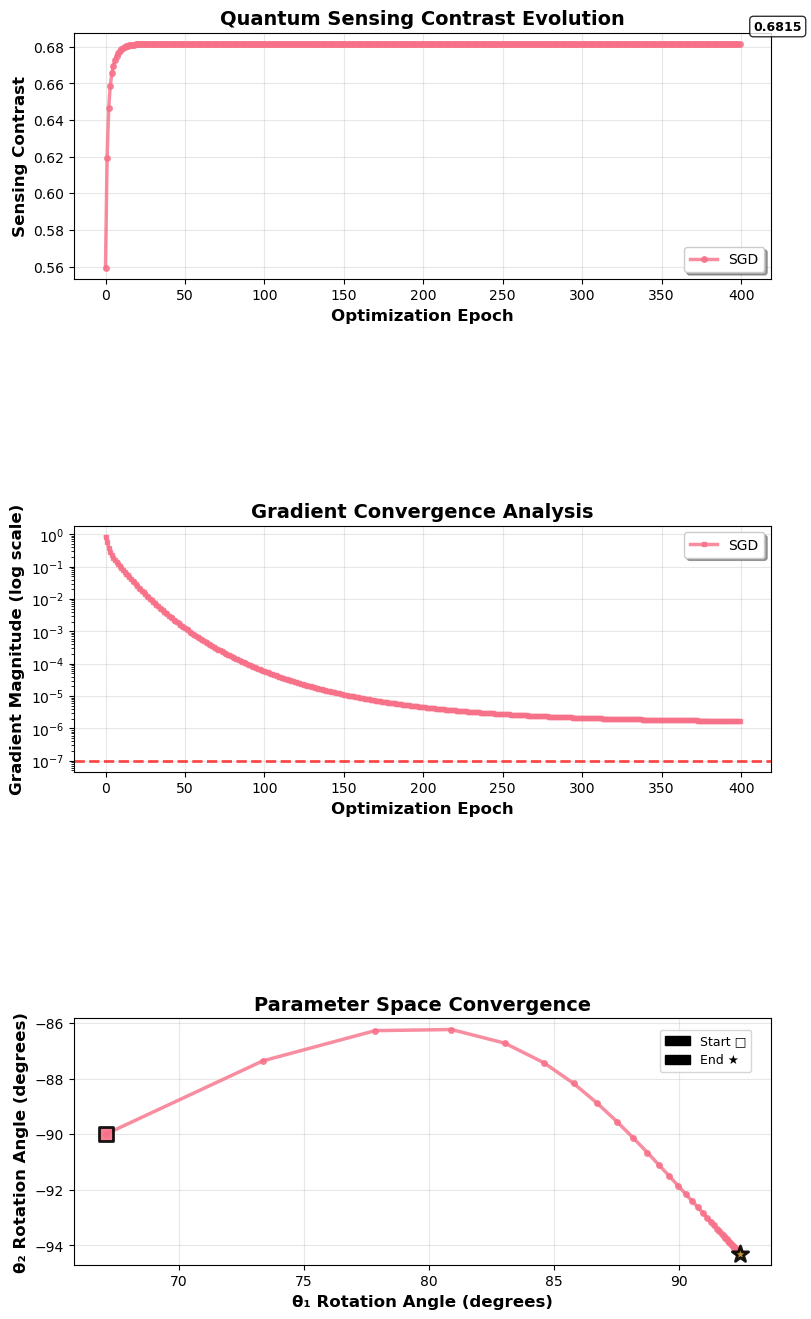

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Set up plotting style for publication quality
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive figure with subplots for optimization analysis
fig = plt.figure(figsize=(9, 16))

# ==================== SENSING CONTRAST EVOLUTION ====================
ax1 = plt.subplot(3, 1, 1)
for method, result in optimization_results.items():
    history = result['history']
    # For manual optimization, use contrast from loss
    epochs = range(len(history['loss']))
    contrast_values = -np.array(history['loss'])
    
    plt.plot(epochs, contrast_values, 
             linewidth=2.5, marker='o', markersize=4, 
             label=f'{method.upper()}', alpha=0.8)

plt.xlabel('Optimization Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Sensing Contrast', fontsize=12, fontweight='bold')
plt.title('Quantum Sensing Contrast Evolution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add final contrast values as text annotations
for i, (method, result) in enumerate(optimization_results.items()):
    final_contrast = result['contrast']
    plt.annotate(f'{final_contrast:.4f}', 
                xy=(len(result['history']['loss'])-1, final_contrast),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                fontsize=9, fontweight='bold')

# ==================== GRADIENT MAGNITUDE EVOLUTION ====================
ax2 = plt.subplot(3, 1, 2)
for method, result in optimization_results.items():
    history = result['history']
    epochs = range(len(history['gradients']))
    
    # Calculate gradient magnitude for each epoch
    grad_magnitudes = []
    for grad_pair in history['gradients']:
        if isinstance(grad_pair, list) and len(grad_pair) == 2:
            mag = np.sqrt(grad_pair[0]**2 + grad_pair[1]**2)
        else:
            mag = abs(grad_pair) if not isinstance(grad_pair, list) else 0
        grad_magnitudes.append(mag)
    
    plt.semilogy(epochs, grad_magnitudes, 
                linewidth=2.5, marker='s', markersize=3,
                label=f'{method.upper()}', alpha=0.8)

plt.xlabel('Optimization Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Gradient Magnitude (log scale)', fontsize=12, fontweight='bold')
plt.title('Gradient Convergence Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add convergence threshold line
plt.axhline(y=1e-7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Tolerance (1e-7)')

# ==================== PARAMETER SPACE CONVERGENCE (2D) ====================
ax3 = plt.subplot(3, 1, 3)
plt.subplots_adjust(hspace=1)

# Create parameter space trajectory plot
for method, result in optimization_results.items():
    history = result['history']
    theta0_traj = np.array(history['theta_values'])[:,0] + np.array(history['theta_values'])[:,1]
    theta1_traj = np.array(history['theta_values'])[:,0] - np.array(history['theta_values'])[:,1]
    
    # Plot optimization trajectory
    plt.plot(np.array(theta0_traj) * 180/np.pi, np.array(theta1_traj) * 180/np.pi, 
             linewidth=2.5, marker='o', markersize=4, alpha=0.8,
             label=f'{method.upper()}')
    
    # Mark starting point
    plt.scatter(theta0_traj[0] * 180/np.pi, theta1_traj[0] * 180/np.pi, 
               s=100, marker='s', edgecolors='black', linewidth=2, 
               alpha=0.9, zorder=5)
    
    # Mark ending point
    plt.scatter(theta0_traj[-1] * 180/np.pi, theta1_traj[-1] * 180/np.pi, 
               s=150, marker='*', edgecolors='black', linewidth=2, 
               alpha=0.9, zorder=5)

plt.xlabel('θ₁ Rotation Angle (degrees)', fontsize=12, fontweight='bold')
plt.ylabel('θ₂ Rotation Angle (degrees)', fontsize=12, fontweight='bold')
plt.title('Parameter Space Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add legend for markers
start_patch = mpatches.Patch(color='black', label='Start □')
end_patch = mpatches.Patch(color='black', label='End ★')
plt.legend(handles=[start_patch, end_patch], loc='upper right', 
          bbox_to_anchor=(0.98, 0.98), fontsize=9)

plt.show()